<div align="center">

<h1> <b> ANÁLISIS DEL ESPECTRO DE ABSORCIÓN DE DIFERENTES CERVEZAS TIPO LAGER </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Cristian Vergara Restrepo <br>
Santiago Ramírez Gaviria</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

---


## Física Experimental IV

### Objetivo general

Analizar el espectro de absorción de diferentes cervezas tipo Lager mediante espectroscopia, comparando cada muestra con el espectro del agua para identificar variaciones relativas en su composición.

### Introducción

El propósito de este experimento es analizar el espectro de absorción de distintas cervezas tipo Lager utilizando un espectroscopio, comparando cada muestra con el espectro del agua. Todas las cervezas analizadas comparten el mismo tipo de elaboración (cervezas tipo Lager), por lo que las diferencias observadas en sus espectros de absorción permiten inferir variaciones relativas en su composición —por ejemplo, en la concentración de compuestos derivados de la malta— que influyen en el color y, potencialmente, en el sabor de la cerveza. Este análisis óptico no permite, sin embargo, establecer una correlación directa con la palatabilidad o el sabor percibido, ya que estos dependen también de otros factores sensoriales que la espectroscopia de absorción no captura.

La comparación del espectro de una bebida frente a un espectro de referencia es, además, el principio detrás de métodos estandarizados de la industria cervecera para cuantificar el color de la cerveza mediante espectrofotometría, como el sistema EBC de la European Brewery Convention (2018).

### Procedimiento experimental

1. **Configuración del espectroscopio:** se utiliza un espectroscopio para medir el espectro de absorción de diferentes muestras de cerveza y compararlas con el del agua. Las cervezas analizadas son Águila, Andina, Budweiser, Club, Corona, Costeñita, Heineken y Pilsen.
2. **Recolección de datos:** los datos se recolectan en el rango de longitud de onda de 400 nm a 900 nm; para cada muestra de cerveza se registra la intensidad de absorción en función de la longitud de onda.
3. **Análisis de datos:** se calculan las diferencias de intensidad de cada cerveza respecto al agua y se identifican, para cada muestra, el pico de absorción principal (pp) y el secundario (sp).


### **Desarrollo y resultados**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


### Carga de los espectros

Cada archivo de datos crudos del espectroscopio contiene 14 líneas de encabezado seguidas de dos columnas separadas por tabulaciones: longitud de onda (nm) e intensidad (cuentas). Se conserva únicamente el rango de filas entre los índices 500 y 2047, correspondiente a la región espectral de interés (aproximadamente 400 nm a 900 nm).


In [ ]:
def cargar_espectro(ruta, indice_inicial=500, indice_final=2047):
    """
    Carga un espectro medido con el espectroscopio y lo recorta al rango
    de interés.

    Parameters
    ----------
    ruta : str
        Ruta al archivo de datos del espectroscopio.
    indice_inicial, indice_final : int
        Límites (en número de fila) de la región espectral conservada.

    Returns
    -------
    wavelength, intensity : numpy.ndarray
        Longitud de onda (nm) e intensidad (cuentas) en el rango recortado.
    """
    df = pd.read_csv(ruta, header=14, sep='\t', names=['wavelength', 'intensity'])
    df = df[indice_inicial:indice_final]
    wavelength = df['wavelength'].to_numpy(dtype='float')
    intensity = df['intensity'].to_numpy(dtype='float')
    return wavelength, intensity


# Espectro de referencia (agua), normalizado por su máximo de intensidad
wavelength, intensity_reference = cargar_espectro('agua-22.csv')
int_norm = intensity_reference / np.max(intensity_reference)


### Espectro de diferencia respecto al agua

Para cada marca de cerveza se promedian todas las repeticiones disponibles y se resta el espectro normalizado del agua. Un valor negativo en el espectro de diferencia indica que la cerveza absorbe más luz que el agua en esa longitud de onda.


In [ ]:
def espectro_diferencia_promedio(marca, wavelength, int_norm, directorio='Data'):
    """
    Calcula el espectro de diferencia de intensidad normalizada de una
    marca de cerveza respecto al agua, promediado sobre todas las
    repeticiones disponibles de esa marca.

    Parameters
    ----------
    marca : str
        Nombre de la marca de cerveza, tal como aparece al inicio del
        nombre de cada archivo en el directorio de datos.
    wavelength : numpy.ndarray
        Longitud de onda de referencia (debe coincidir con la de las
        muestras de cerveza).
    int_norm : numpy.ndarray
        Intensidad normalizada del agua, usada como referencia.
    directorio : str
        Carpeta donde se encuentran los archivos de datos de las cervezas.

    Returns
    -------
    numpy.ndarray
        Diferencia de intensidad normalizada, promediada sobre las
        repeticiones disponibles de la marca.
    """
    resultados = []
    for archivo in os.listdir(directorio):
        if archivo[0:-7] == marca:
            _, muestra = cargar_espectro(os.path.join(directorio, archivo))
            resultados.append(muestra / np.max(muestra) - int_norm)
    return np.mean(np.array(resultados), axis=0)


### Identificación de los picos de absorción

El espectro de diferencia se divide en dos regiones: la primera, de menor longitud de onda, donde se ubica el pico de absorción principal; y la segunda, de mayor longitud de onda, donde se ubica el pico secundario. En cada región, el pico corresponde al mínimo de la diferencia de intensidad, y se expresa como un porcentaje de absorción adicional respecto al agua.


In [ ]:
def detectar_picos_absorcion(wavelength, diferencia, indice_division):
    """
    Localiza el pico de absorción principal y el secundario en un
    espectro de diferencia frente al agua.

    Parameters
    ----------
    wavelength : numpy.ndarray
        Longitud de onda (nm) del espectro.
    diferencia : numpy.ndarray
        Diferencia de intensidad normalizada respecto al agua.
    indice_division : int
        Índice que separa la región del pico principal de la del pico
        secundario.

    Returns
    -------
    tuple
        (longitud de onda del pico principal, porcentaje de absorción
        del pico principal, longitud de onda del pico secundario,
        porcentaje de absorción del pico secundario).
    """
    primera_region = diferencia[:indice_division]
    segunda_region = diferencia[indice_division:]

    pico_principal_nm = wavelength[:indice_division][np.argmin(primera_region)]
    pico_principal_pct = round(-100 * np.min(primera_region), 1)

    pico_secundario_nm = wavelength[indice_division:][np.argmin(segunda_region)]
    pico_secundario_pct = round(-100 * np.min(segunda_region), 1)

    return pico_principal_nm, pico_principal_pct, pico_secundario_nm, pico_secundario_pct


### Cálculo y visualización de los espectros de absorción

Se calcula el espectro de diferencia y se localizan sus picos de absorción para cada marca de cerveza, y se grafican todos los espectros junto con el del agua como referencia implícita (diferencia igual a cero).


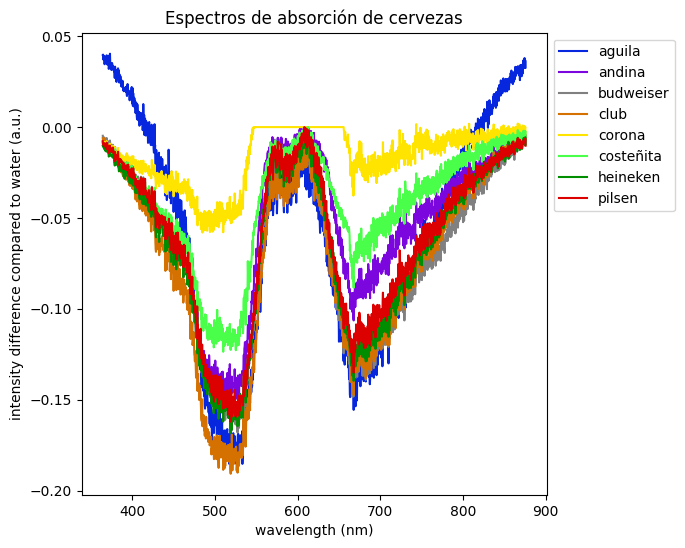

In [ ]:
colores = {
    'aguila': '#0627de',
    'andina': '#7c06de',
    'budweiser': '#808080',
    'club': '#d57100',
    'corona': '#ffe400',
    'costeñita': '#4aff4a',
    'heineken': '#008e00',
    'pilsen': '#dd0000',
}

pp_ab_nm, pp_ab_por = [], []
sp_ab_nm, sp_ab_por = [], []

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.set_title('Espectros de absorción de cervezas')
ax.set_xlabel('wavelength (nm)')
ax.set_ylabel('intensity difference compared to water (a.u.)')

for marca in colores:
    diferencia = espectro_diferencia_promedio(marca, wavelength, int_norm)

    pico_pp_nm, pico_pp_pct, pico_sp_nm, pico_sp_pct = detectar_picos_absorcion(
        wavelength, diferencia, indice_division=750
    )
    pp_ab_nm.append(pico_pp_nm)
    pp_ab_por.append(pico_pp_pct)
    sp_ab_nm.append(pico_sp_nm)
    sp_ab_por.append(pico_sp_pct)

    ax.plot(wavelength, diferencia, label=marca, color=colores[marca])

ax.legend(loc='upper left', bbox_to_anchor=(1, 1))


In [ ]:
Resume = {
    'Marca de cerveza': ['aguila', 'andina', 'budweiser', 'club', 'corona', 'costeñita', 'heineken', 'pilsen'],
    'Primer pico de absorción (nm)': pp_ab_nm,
    'Porcentaje de absorción pp': pp_ab_por,
    'segundo pico de absorción (nm)': sp_ab_nm,
    'Porcentaje de absorción sp': sp_ab_por,
}


### **Tabla de picos de absorción**

In [ ]:
pd.DataFrame(Resume)


,Marca de cerveza,Primer pico de absorción (nm),Porcentaje de absorción pp,segundo pico de absorción (nm),Porcentaje de absorción sp
0,aguila,533.29,18.5,667.89,15.6
1,andina,529.15,15.2,667.89,10.6
2,budweiser,527.42,16.8,666.58,14.8
3,club,519.11,19.1,667.89,14.7
4,corona,484.95,5.8,667.56,3.8
5,costeñita,510.08,12.4,667.89,8.8
6,heineken,518.76,16.8,667.89,14.0
7,pilsen,518.76,16.2,667.89,13.5


### Análisis

Observando los espectros de absorción y la tabla de picos de absorción, se destacan los siguientes puntos:

- **Águila** presenta un pico de absorción principal relativamente alto, a 533.29 nm con un 18.5 % de absorción, lo que indica una concentración notable de compuestos absorbentes en esa longitud de onda.
- **Corona** presenta los valores más bajos tanto en el pico principal (484.95 nm, 5.8 %) como en el secundario (667.56 nm, 3.8 %), lo que sugiere una menor concentración de los compuestos responsables de la absorción en comparación con las demás cervezas.
- **Club** muestra el mayor porcentaje de absorción en el pico principal, con un 19.1 %, lo que podría indicar una mayor cantidad de compuestos que absorben en esa región del espectro.
- La similitud en la longitud de onda del pico secundario (alrededor de 667.89 nm) para la mayoría de las cervezas sugiere que los compuestos responsables de esta absorción son comunes a todas las muestras analizadas.
- Alrededor de 600 nm se observa una región plana en los espectros de absorción, resultado de la saturación del espectroscopio en esa longitud de onda; al comparar los espectros de las cervezas con el del agua, esta saturación se traduce en una diferencia de intensidad igual a cero en esa zona.

Estos resultados permiten inferir diferencias en la composición de las cervezas tipo Lager analizadas, posiblemente asociadas a variaciones en la concentración de ingredientes como la malta, el lúpulo y otros aditivos que inciden en sus propiedades ópticas y, de manera indirecta, en su sabor.

### Conclusiones

- Se identificaron variaciones significativas en los espectros de absorción de las diferentes cervezas tipo Lager analizadas.
- Los picos de absorción permiten inferir diferencias en la composición de las cervezas, posiblemente asociadas a variaciones en la concentración de ingredientes como la malta.
- Este análisis constituye una herramienta útil para relacionar los ingredientes de una cerveza con sus propiedades ópticas, aunque sus resultados no pueden correlacionarse directamente con el sabor percibido.
- La región plana observada alrededor de 600 nm, atribuible a la saturación del espectroscopio, es un aspecto a tener en cuenta en futuros experimentos para mejorar la precisión de las mediciones.


### Referencias

- European Brewery Convention. (2018). *Analytica-EBC, method 9.6: Colour of beer, spectrophotometric method*. EBC. (No fue posible confirmar el número de edición exacto consultado).
- American Society of Brewing Chemists. (2011). *Methods of analysis: Beer-10, color of beer*. ASBC. (No fue posible confirmar el número de edición exacto consultado).
- Skoog, D. A., Holler, F. J., & Crouch, S. R. (2017). *Principles of instrumental analysis* (7th ed.). Cengage Learning.
